In [1]:
import numpy as np
import pandas as pd
from pysam import VariantFile
import scipy.stats as stats
from scipy.stats import norm
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
%matplotlib inline
import seaborn as sns
sns.set_style("whitegrid")
import os
import geopandas as gpd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Patch
import glob
from sklearn.linear_model import LinearRegression

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v1.min40_split"
dftisa = pd.read_csv(f'{path}/../tissue40.list', sep='\t')
tisorder = pd.read_csv("/storage/public/home/2020060185/jupyter/GTEx/00.metadata/tissue.order",sep="\t")
palette = tisorder.set_index('Tissue (QTL)')['Color'].to_dict()

In [3]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v9.breed_specific"
dftis = pd.read_csv(f'{path}/v1.anc/tissue.filtered2.list', sep='\t')
tislist = list(dftis['Tissue'])
dfanc = pd.melt(dftis, id_vars=['Tissue'], value_vars=['Europe', 'Central_and_East_Asia'], 
           var_name='group', value_name='Sample size')
dfbred = pd.read_csv(f'{path}/v2.breed/k.txt', sep='\t', header=None, usecols=[0,1,4],
                     names=['Tissue','breed','Sample size']).rename(columns={'breed':'group'})
dfall = dftisa.loc[dftisa['Tissue'].isin(tislist), ['Tissue','Sample size']]
dfall['group'] = 'All'
dftis = pd.concat([dfall, dfanc, dfbred])
dftis

,Tissue,Sample size,group
0,Muscle,713,All
1,Liver,567,All
2,Adipose,491,All
3,Brain,481,All
4,Longissimus_muscle,419,All
...,...,...,...
24,Abomasum,43,Hu
25,Abomasum,49,Merino
26,Heart,59,Hu
27,Heart,44,Small-tailed_Han


In [4]:
color_dict = {
    'eQTL': '#FC3726',
    'eeQTL': '#FFC300',
    'isoQTL': '#FF8D1A',
    'enQTL': '#CD853F',
    'sQTL': '#55A868',
    'stQTL': '#3A5FCD',
    "3aQTL": '#984EA3'}
color_dict1 = {
    '1': '#F6B48F',
    '2': '#F37651',
    '3': '#AD1759',
    '4': '#35193E'}

# Fig. 8a

In [5]:
from itertools import cycle
import re

def clean_genelist(genelist):
    no_brackets = re.sub(r'\(.*?\)', '', genelist)
    #genes = [gene for gene in no_brackets.split(',') if not gene.startswith('LOC') and gene]
    genes = [gene for gene in no_brackets.split(',')]
    return ','.join(genes)

def manhattan_plot(df, chr_col, loc_col, val_col, xlabel, ylabel, 
                   cutoff=None, highlight=None, annotation=None, ann_col=None, ylim=None, invert_yaxis=False, top_xaxis=False, ticklabelsize=12, figsize=(20, 4), axlabelsize=12, markersize=12):
    sns.set_theme(style="ticks")
    fig, ax = plt.subplots(1, 1, figsize=figsize)
#    offsets = {}
    loc_offset = 0
    xticks = []
    xticklabels = []
    for chrom, color in zip(df[chr_col].unique(), cycle(['#949597', '#D6D7D9'])):
#        offsets[chrom] = loc_offset
        tmpdf = df[df[chr_col]==chrom]
        tmpdf.loc[:, loc_col] += loc_offset
        xticklabels.append(chrom)
        xticks.append(tmpdf[loc_col].median())
        tmpdf.plot(kind='scatter', x=loc_col, y=val_col, ax=ax, s=markersize, color=color, marker='o', alpha=0.8)
        if isinstance(highlight, pd.DataFrame):
            hdf = highlight.loc[highlight[chr_col]==chrom, [loc_col, val_col, 'color']]
            if hdf.shape[0] > 0:
                hdf[loc_col] += loc_offset
                hdf.plot(kind='scatter', x=loc_col, y=val_col, ax=ax, s=markersize, color=hdf['color'], marker='o', alpha=0.8)
        if cutoff:
            #ax.hlines(cutoff[chrom], tmpdf[loc_col].values[0], tmpdf[loc_col].values[-1])
            ax.hlines(cutoff, tmpdf[loc_col].values[0], tmpdf[loc_col].values[-1], color='r', linestyle='--')
        if isinstance(annotation, pd.DataFrame):
            for index, row in annotation[annotation[chr_col]==chrom].iterrows():
                anndf = df[(df[chr_col]==chrom)&(df['BIN_START']>=row['BIN_START'])&(df['BIN_END']<=row['BIN_END'])]
                x, y = row[loc_col]+loc_offset, row[val_col]
                genes = row[ann_col]
                plt.plot([x, x], [y, y + 0.1], 'k--', linewidth=0.5, alpha=0.5)  # 虚线
                plt.text(x, y + 0.1, genes, fontsize=10, ha='center', va='bottom', fontstyle='italic', 
                         bbox=dict(facecolor='white', alpha=0.2, edgecolor='none', pad=0.2))
        loc_offset = tmpdf[loc_col].values[-1] # assume loc is sorted
        
    ax.set_xlabel(xlabel, fontsize=axlabelsize)
    ax.set_ylabel(ylabel, fontsize=axlabelsize)
    plt.xticks(xticks, xticklabels)
    ax.set_xlim([df[loc_col].values[0], tmpdf[loc_col].values[-1]])
    if ylim:
        ax.set_ylim(ylim)
    if invert_yaxis:
        ax.invert_yaxis()
    if top_xaxis:
        ax.xaxis.tick_top()
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.xaxis.set_label_position('top')
    else:
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontsize(ticklabelsize)

In [6]:
path = "/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/06.population/02.selection"
# input fst
fst = pd.read_csv(f"{path}/01.fst/eur_cea/chrAuto.50000_10000.windowed.weir.fst.filter", sep="\t")
fst['CHROM'] = fst['CHROM'].str.replace('chr', '', regex=False).astype(int)
fst = fst.sort_values(by=['CHROM', 'BIN_END'], ascending=[True, True])
fst_sel = pd.read_csv(f"{path}/01.fst/eur_cea/chrAuto.50000_10000.windowed.weir.fst.filter.t0.01", sep="\t")
fst_cutoff = fst_sel['WEIGHTED_FST'].min()

In [22]:
# input gene annotation
fst_ann = pd.read_csv(f"{path}/01.fst/eur_cea/chrAuto.50000_10000.windowed.weir.fst.filter.t0.01.annotation", sep="\t")
fst_ann['CHROM'] = fst_ann['CHROM'].str.replace('chr', '', regex=False).astype(int)
# remove brackets
fst_ann['cleaned_ann'] = fst_ann['ann'].apply(clean_genelist)
fst_ann['split_cleaned_ann'] = fst_ann['cleaned_ann'].str.split(',')
fst_ann_explode = fst_ann.explode('split_cleaned_ann').reset_index(drop=True)
# extract the max result for each gene
max_fst_indices = fst_ann_explode.groupby('split_cleaned_ann')['WEIGHTED_FST'].idxmax()
fst_ann_explode_filter = fst_ann_explode.loc[max_fst_indices]

# overlap with published genes
#df_published = pd.read_csv("/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v9.breed_specific/v1.anc/all_eqtl.unique.selection.sheep.genelist",
#                            sep="\t", header = None, names=['geneID'])
df_published = pd.read_csv(f"{path}/01.fst/sheep_genes_selected.list", sep="\t", header = None, names=['geneID'])
published_genelist = list(df_published['geneID'].values)
fst_ann_explode_filter_publised = fst_ann_explode_filter[fst_ann_explode_filter['split_cleaned_ann'].isin(published_genelist)]
fst_ann_explode_filter_publised_top10 = fst_ann_explode_filter_publised.sort_values(by='WEIGHTED_FST', ascending=False).head(15)
fst_ann_explode_filter_publised_top10 = pd.concat([fst_ann_explode_filter_publised_top10, fst_ann_explode_filter[fst_ann_explode_filter['split_cleaned_ann'].isin(['CCL25','RIPK'])]])

In [25]:
fst_ann_explode_filter.sort_values(by='WEIGHTED_FST', ascending=False).head(25)

,CHROM,BIN_START,BIN_END,N_VARIANTS,WEIGHTED_FST,MEAN_FST,type,ann,cleaned_ann,split_cleaned_ann
0,12,54090001,54140000,150,0.580700,0.554759,exonic,AADACL3,AADACL3,AADACL3
1,8,62990001,63040000,100,0.578837,0.554189,exonic,TNFAIP3,TNFAIP3,TNFAIP3
5,12,54050001,54100000,319,0.567437,0.497743,exonic,"AADACL3,C12H1orf158","AADACL3,C12H1orf158",C12H1orf158
10,1,28080001,28130000,145,0.555586,0.436277,exonic,GLIS1,GLIS1,GLIS1
15,8,62970001,63020000,118,0.537820,0.469424,intergenic,"OLIG3(dist=296775),TNFAIP3(dist=5484)","OLIG3,TNFAIP3",OLIG3
21,12,57050001,57100000,119,0.516666,0.087531,exonic,PAPPA2,PAPPA2,PAPPA2
33,3,215090001,215140000,134,0.467383,0.342654,intronic,MICAL3,MICAL3,MICAL3
35,4,48230001,48280000,110,0.460915,0.341111,exonic,ATXN7L1,ATXN7L1,ATXN7L1
37,18,19530001,19580000,1514,0.454758,0.429949,exonic,"LOC101121887,LOC101122387","LOC101121887,LOC101122387",LOC101122387
36,18,19530001,19580000,1514,0.454758,0.429949,exonic,"LOC101121887,LOC101122387","LOC101121887,LOC101122387",LOC101121887


In [23]:
fst_ann_explode_filter_publised_top10

,CHROM,BIN_START,BIN_END,N_VARIANTS,WEIGHTED_FST,MEAN_FST,type,ann,cleaned_ann,split_cleaned_ann
10,1,28080001,28130000,145,0.555586,0.436277,exonic,GLIS1,GLIS1,GLIS1
21,12,57050001,57100000,119,0.516666,0.087531,exonic,PAPPA2,PAPPA2,PAPPA2
58,20,49680001,49730000,369,0.431115,0.311706,exonic,RIPK1,RIPK1,RIPK1
108,25,6760001,6810000,228,0.396449,0.302010,exonic,"IRF2BP2,LOC101111733","IRF2BP2,LOC101111733",IRF2BP2
152,13,49200001,49250000,215,0.371209,0.297438,intergenic,"BMP2(dist=310140),LOC101117953(dist=192346)","BMP2,LOC101117953",BMP2
163,8,88880001,88930000,670,0.363800,0.261651,exonic,TBXT,TBXT,TBXT
387,14,52200001,52250000,315,0.318207,0.238857,exonic,"CEACAM19,IGSF23,PVR","CEACAM19,IGSF23,PVR",PVR
487,19,31820001,31870000,367,0.306381,0.256346,intronic,MITF,MITF,MITF
1432,6,38010001,38060000,138,0.230893,0.201505,exonic,"LCORL,NCAPG","LCORL,NCAPG",LCORL
1669,15,3790001,3840000,633,0.222454,0.167418,intergenic,"LOC106991615(dist=323864),PDGFD(dist=120065)","LOC106991615,PDGFD",PDGFD


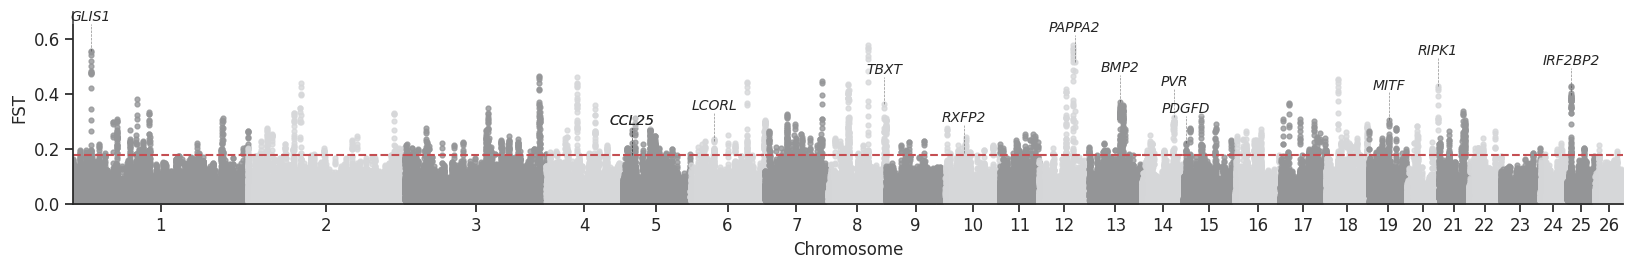

In [24]:
manhattan_plot(fst, 'CHROM', 'BIN_END', 'WEIGHTED_FST', 'Chromosome', 'FST', cutoff=fst_cutoff,
               annotation=fst_ann_explode_filter_publised_top10, ann_col='split_cleaned_ann', ylim=(0, 0.7), figsize=(20, 2.5))
plt.savefig("pdf/manhattan_FST_new.pdf", bbox_inches='tight')

# Fig. 8b

In [121]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/06.population/02.selection/mashr_enrichment/gene1"
df = pd.DataFrame()
for i in [1,2,3,49,50,51]:
    if os.path.isfile(f'{path}/lfsr{i}/tissues/OR_results.csv'):
        df_ = pd.read_csv(f'{path}/lfsr{i}/tissues/OR_results.csv')
        df_['Tissues with LFSR < 0.05'] = i
        df = pd.concat([df, df_])
df['QTL'] = df['QTL'].str.replace('.txt', '', regex=False)
df['Annotation'] = df['Annotation'].replace({'fst00.txt':1, 'fst01.txt':2, 'fst02.txt':3, 'fst03.txt':4, 'fst04.txt':5,
                                             'fst05.txt':6, 'fst06.txt':7, 'fst07.txt':8, 'fst08.txt':9, 'fst09.txt':10})
df['log2(odds ratio)'] = np.log2(df['Odds ratio'])
df = df.replace([np.inf, -np.inf], np.nan).dropna()
#df = df[df['P-value']<0.05]
df

/storage/public/home/2020060185/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


,QTL,Annotation,Odds ratio,95% CI Low,95% CI High,P-value,num_var,Tissues with LFSR < 0.05,log2(odds ratio)
0,Adenohypophysis,6,1.059150,1.012388,1.108073,1.302523e-02,9036,1,0.082908
1,Adenohypophysis,3,0.859596,0.817362,0.904012,2.530718e-09,9036,1,-0.218270
2,Adenohypophysis,4,0.857275,0.816268,0.900343,4.633188e-10,9036,1,-0.222170
3,Adenohypophysis,5,1.108677,1.059823,1.159782,8.458058e-06,9036,1,0.148839
4,Adenohypophysis,8,0.758748,0.723009,0.796254,2.121082e-30,9036,1,-0.398307
...,...,...,...,...,...,...,...,...,...
495,Hypothalamus,1,1.333255,1.320223,1.346416,0.000000e+00,296245,51,0.414953
496,Hypothalamus,10,1.143714,1.133607,1.153910,1.479410e-189,296245,51,0.193726
497,Hypothalamus,9,0.982568,0.974355,0.990850,3.974475e-05,296245,51,-0.025371
498,Hypothalamus,2,1.004775,0.995551,1.014083,3.111821e-01,296245,51,0.006872


/tmp/ipykernel_9749/130446204.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfplot.loc[dfplot['Tissues with LFSR < 0.05']<=3, 'Shared tissues'] = 3


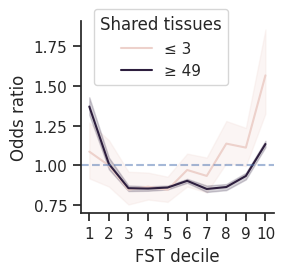

In [122]:
for num in [200]:
    dfplot = df[(df['num_var']>num)&(df['Tissues with LFSR < 0.05']<=3)|(df['Tissues with LFSR < 0.05']>=49)]
    dfplot.loc[dfplot['Tissues with LFSR < 0.05']<=3, 'Shared tissues'] = 3
    dfplot.loc[dfplot['Tissues with LFSR < 0.05']>=49, 'Shared tissues'] = 49

    sns.set_theme(style="ticks")
    plt.figure(figsize=(2.5, 2.5))
    ax = sns.lineplot(data=dfplot, x="Annotation", y='Odds ratio', hue="Shared tissues")
    #ax = sns.lineplot(data=dfplot, x="Annotation", y='log2(Odds ratio)', hue="Tissues with LFSR < 0.05")
    ax.xaxis.set_major_locator(MultipleLocator(1))
    plt.xlabel('FST decile')
    plt.ylabel('Odds ratio')
    sns.move_legend(ax, "upper left", labels=['≤ 3', '≥ 49'], bbox_to_anchor=(0.03, 1.1))
    plt.axhline(y=1, color='b', alpha=.5, linestyle='--')
    #plt.axhline(y=0, color='b', alpha=.5, linestyle='--')
    sns.despine()
plt.savefig("pdf/FST_tis-share.pdf", bbox_inches='tight')

ymin, ymax = ax.get_ylim()

In [123]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/06.population/02.selection/mashr_enrichment/gene1"
df = pd.DataFrame()
for i in [1,2,3,49,50,51]:
    if os.path.isfile(f'{path}/lfsr{i}/tissues/OR_control_results.csv'):
        df_ = pd.read_csv(f'{path}/lfsr{i}/tissues/OR_control_results.csv')
        df_['Tissues with LFSR < 0.05'] = i
        df = pd.concat([df, df_])
df['QTL'] = df['QTL'].str.replace('.txt', '', regex=False)
df['Annotation'] = df['Annotation'].replace({'fst00.txt':1, 'fst01.txt':2, 'fst02.txt':3, 'fst03.txt':4, 'fst04.txt':5,
                                             'fst05.txt':6, 'fst06.txt':7, 'fst07.txt':8, 'fst08.txt':9, 'fst09.txt':10})
df['log2(odds ratio)'] = np.log2(df['Odds ratio'])
df = df.replace([np.inf, -np.inf], np.nan).dropna()
#df = df[df['P-value']<0.05]
df

,QTL,Annotation,Odds ratio,95% CI Low,95% CI High,P-value,num_var,Tissues with LFSR < 0.05,log2(odds ratio)
0,Adenohypophysis,6,0.955278,0.941003,0.969769,2.326740e-09,86809,1,-0.066007
1,Adenohypophysis,3,0.948859,0.933808,0.964152,1.040598e-10,86809,1,-0.075735
2,Adenohypophysis,4,0.933477,0.918997,0.948186,4.194431e-18,86809,1,-0.099313
3,Adenohypophysis,5,0.943389,0.929139,0.957856,4.911395e-14,86809,1,-0.084076
4,Adenohypophysis,8,0.965680,0.951422,0.980152,4.044526e-06,86809,1,-0.050382
...,...,...,...,...,...,...,...,...,...
495,Hypothalamus,1,0.934442,0.917404,0.951797,3.514022e-13,97105,51,-0.097823
496,Hypothalamus,10,1.208038,1.190324,1.226016,1.094815e-134,97105,51,0.272666
497,Hypothalamus,9,1.096580,1.081425,1.111948,4.067712e-38,97105,51,0.133011
498,Hypothalamus,2,0.892583,0.878288,0.907110,3.421615e-44,97105,51,-0.163942


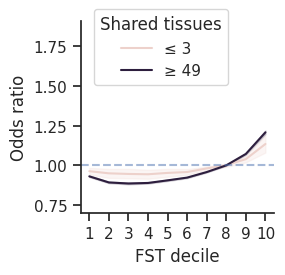

In [124]:
#from matplotlib.ticker import MultipleLocator

for num in [200]:
    dfplot = df[(df['num_var']>num)&(df['Tissues with LFSR < 0.05']<=3)|(df['Tissues with LFSR < 0.05']>=49)]
    dfplot.loc[dfplot['Tissues with LFSR < 0.05']<=3, 'Shared tissues'] = 3
    dfplot.loc[dfplot['Tissues with LFSR < 0.05']>=49, 'Shared tissues'] = 49

    sns.set_theme(style="ticks")
    plt.figure(figsize=(2.5, 2.5))
    ax = sns.lineplot(data=dfplot, x="Annotation", y='Odds ratio', hue="Shared tissues")
    ax.set_ylim(ymin, ymax)
    ax.xaxis.set_major_locator(MultipleLocator(1))
    plt.xlabel('FST decile')
    plt.ylabel('Odds ratio')
    sns.move_legend(ax, "upper left", labels=['≤ 3', '≥ 49'], bbox_to_anchor=(0.03, 1.1))
    plt.axhline(y=1, color='b', alpha=.5, linestyle='--')
    #plt.axhline(y=0, color='b', alpha=.5, linestyle='--')
    sns.despine()
plt.savefig("pdf/FST_tis-share_control.pdf", bbox_inches='tight')

# Fig. 8c

In [154]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/06.population/02.selection/mashr_enrichment/gene2"
#path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/06.population/02.selection/mashr_enrichment/gene2_combined"
df = pd.DataFrame()
for i in [1,2,3, 49,50,51]:
    if os.path.isfile(f'{path}/lfsr{i}/tissues/OR_results.csv'):
        df_ = pd.read_csv(f'{path}/lfsr{i}/tissues/OR_results.csv')
        df_['Tissues with LFSR < 0.05'] = i
        df_['Source'] = 'eQTL'
        df = pd.concat([df, df_])
    if os.path.isfile(f'{path}/lfsr{i}/tissues/OR_control_results.csv'):
        df_ = pd.read_csv(f'{path}/lfsr{i}/tissues/OR_control_results.csv')
        df_['Tissues with LFSR < 0.05'] = i
        df_['Source'] = 'Control'
        df = pd.concat([df, df_])

df['QTL'] = df['QTL'].str.replace('.txt', '', regex=False)
df['Annotation'] = df['Annotation'].replace({'fst10.txt': '10%', 'fst20.txt': '5%', 'fst50.txt': '2%', 'fst100.txt': '1%'})
df['log2(odds ratio)'] = np.log2(df['Odds ratio'])
df = df.replace([np.inf, -np.inf], np.nan).dropna()
df = pd.merge(dftisa[['Tissue','Sample size']], df, left_on=['Tissue'], right_on=['QTL'])
df

/storage/public/home/2020060185/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Tissue,Sample size,QTL,Annotation,Odds ratio,95% CI Low,95% CI High,P-value,num_var,Tissues with LFSR < 0.05,Source,log2(odds ratio)
0,Muscle,713,Muscle,1%,0.509472,0.241625,1.074233,7.272782e-02,509,1,eQTL,-0.972924
1,Muscle,713,Muscle,5%,2.298870,1.871097,2.824442,2.233004e-13,509,1,eQTL,1.200925
2,Muscle,713,Muscle,10%,1.372130,1.129522,1.666847,1.779740e-03,509,1,eQTL,0.456417
3,Muscle,713,Muscle,2%,0.449195,0.253368,0.796375,3.244400e-03,509,1,eQTL,-1.154587
4,Muscle,713,Muscle,1%,1.684898,1.608274,1.765173,1.464007e-92,43294,1,Control,0.752662
...,...,...,...,...,...,...,...,...,...,...,...,...
2133,Oviduct,40,Oviduct,2%,4.360575,3.259510,5.833582,2.159138e-17,295,51,eQTL,2.124519
2134,Oviduct,40,Oviduct,1%,1.530841,1.439059,1.628476,6.139609e-37,26438,51,Control,0.614324
2135,Oviduct,40,Oviduct,5%,1.312241,1.268079,1.357942,2.336203e-51,26438,51,Control,0.392033
2136,Oviduct,40,Oviduct,10%,1.190531,1.157595,1.224403,3.357713e-33,26438,51,Control,0.251605


/tmp/ipykernel_9749/2119717954.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


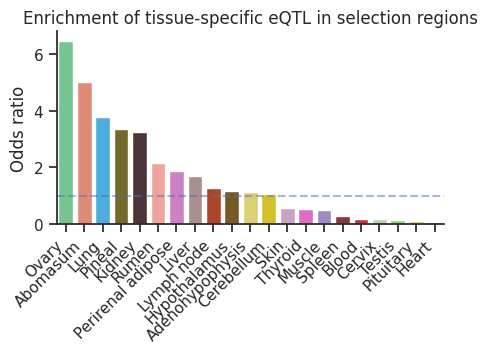

In [148]:
dfplot = df[(df['Tissues with LFSR < 0.05']==1)&(df['num_var']>200)&(df['Annotation']=='1%')&(df['Source']=='eQTL')].sort_values('Odds ratio', ascending=False)
#dfplot['Tissue'] = dfplot['Tissue'].replace('_', ' ', regex=True)

sns.set_theme(style="ticks")
fig=plt.figure(figsize=(5, 2.5))

ax = sns.barplot(dfplot, x="Tissue", y="Odds ratio", palette=palette)
plt.xticks(rotation=45, ha='right')
new_labels = [label.get_text().replace('_', ' ') for label in ax.get_xticklabels()]
ax.set_xticklabels(new_labels)
plt.axhline(y=1, color='b', alpha=.5, linestyle='--')

plt.xlabel('')
plt.title('Enrichment of tissue-specific eQTL in selection regions')
sns.despine()
plt.savefig("pdf/tis-spe_eqtl_enrich_bar.pdf", bbox_inches='tight')

# Fig. 8d

In [9]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v9.breed_specific/fst_enrichment"

# focal SNPs
df1 = pd.DataFrame()
for tis in tislist:
    if os.path.isfile(f'{path}/{tis}/standard/OR_results.csv'):
        df_ = pd.read_csv(f'{path}/{tis}/standard/OR_results.csv')
        df_['Tissue'] = tis
        df_['Type'] = 'standard'
        df_['QTL'] = 'standard ' + df_['QTL']
        df1 = pd.concat([df1, df_])
    if os.path.isfile(f'{path}/{tis}/stratified/OR_results.csv'):
        df_ = pd.read_csv(f'{path}/{tis}/stratified/OR_results.csv')
        df_['Tissue'] = tis
        df_['Type'] = 'stratified'
        df_['QTL'] = 'stratified ' + df_['QTL']
        df1 = pd.concat([df1, df_])
    if os.path.isfile(f'{path}/{tis}/specific/OR_results.csv'):
        df_ = pd.read_csv(f'{path}/{tis}/specific/OR_results.csv')
        df_['Tissue'] = tis
        df_['Type'] = 'specific'
        df_['QTL'] = 'specific ' + df_['QTL']
        df1 = pd.concat([df1, df_])
df1['Source'] = 'molQTL'

# control SNPs
df2 = pd.DataFrame()
for tis in tislist:
    if os.path.isfile(f'{path}/{tis}/standard/OR_control_results.csv'):
        df_ = pd.read_csv(f'{path}/{tis}/standard/OR_control_results.csv')
        df_['Tissue'] = tis
        df_['Type'] = 'standard'
        df_['QTL'] = 'standard ' + df_['QTL']
        df2 = pd.concat([df2, df_])
    if os.path.isfile(f'{path}/{tis}/stratified/OR_control_results.csv'):
        df_ = pd.read_csv(f'{path}/{tis}/stratified/OR_control_results.csv')
        df_['Tissue'] = tis
        df_['Type'] = 'stratified'
        df_['QTL'] = 'stratified ' + df_['QTL']
        df2 = pd.concat([df2, df_])
    if os.path.isfile(f'{path}/{tis}/specific/OR_control_results.csv'):
        df_ = pd.read_csv(f'{path}/{tis}/specific/OR_control_results.csv')
        df_['Tissue'] = tis
        df_['Type'] = 'specific'
        df_['QTL'] = 'specific ' + df_['QTL']
        df2 = pd.concat([df2, df_])
df2['Source'] = 'Control'

# merge
df = pd.concat([df1, df2], ignore_index=True)
df['QTL'] = df['QTL'].str.replace('.txt', '', regex=False)
df['Annotation'] = df['Annotation'].replace({'selection.txt': 'selection', 'fst0_0.05.txt': '0-0.05', 'fst0.05_0.15.txt': '0.05-0.15',
                                             'fst0.15_0.25.txt': '0.15-0.25', 'fst0.25.txt': '>0.25'})
df['Type'] = df['Type'].str.replace('.txt', '', regex=False)
df['log2(odds ratio)'] = np.log2(df['Odds ratio'])
df = df.replace([np.inf, -np.inf], np.nan)
df_selection = df[df['Annotation']=='selection'].reset_index()

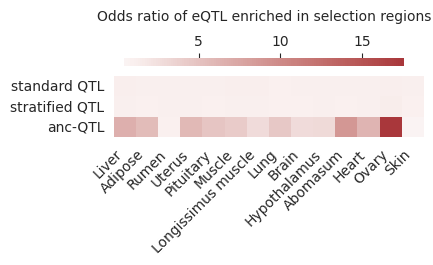

In [16]:
df_selection_mean = df_selection[df_selection['Source']=='molQTL'].groupby(['Tissue','QTL'])['Odds ratio'].mean().reset_index()
df_selection_mean['Tissue'] = df_selection_mean['Tissue'].replace('_', ' ', regex=True)
df_selection_mean_pivot = df_selection_mean.pivot(columns='Tissue', index='QTL', values='Odds ratio')
col_order = ['Liver', 'Adipose', 'Rumen', 'Uterus', 'Pituitary', 'Muscle', 'Longissimus muscle',
 'Lung', 'Brain', 'Hypothalamus', 'Abomasum', 'Heart', 'Ovary', 'Skin']
df_selection_mean_pivot = df_selection_mean_pivot.rename(index={'standard eQTL':'standard QTL', 'stratified eQTL':'stratified QTL', 'specific eQTL':'anc-QTL'})
row_order = ['standard QTL', 'stratified QTL', 'anc-QTL']
df_selection_mean_pivot_reordered = df_selection_mean_pivot.loc[row_order, col_order]

fig = plt.figure(figsize=(4, 0.8))
ax = sns.heatmap(df_selection_mean_pivot_reordered, center=0, cmap='vlag', cbar=False)
ax.set(xlabel="", ylabel="")
plt.xticks(rotation=45, ha='right')
cax = fig.add_axes([0.15, 1, 0.7, 0.1])  # [left, bottom, width, height]
cbar = plt.colorbar(ax.collections[0], cax=cax, orientation="horizontal")
cbar.outline.set_linewidth(0)
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')
cbar.set_label("Odds ratio of eQTL enriched in selection regions", labelpad=10)
plt.savefig("pdf/diffqtl_tis.pdf", bbox_inches='tight')

# Fig. 8e-n

## functions2

In [13]:
fst = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/06.population/02.selection/04.TajimaD/eur_cea/chrAuto.10000.windowed.weir.fst.filter', sep='\t')
pi1 = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/06.population/02.selection/04.TajimaD/eur/chrAuto.10000.windowed.pi.filter', sep='\t')
pi1['group'] = 'EUR'
pi2 = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/06.population/02.selection/04.TajimaD/cea/chrAuto.10000.windowed.pi.filter', sep='\t')
pi2['group'] = 'CEA'
pi = pd.concat([pi1, pi2]).reset_index()
tajimad1 = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/06.population/02.selection/04.TajimaD/eur/chrAuto.10000.Tajima.D.filter', sep='\t')
tajimad1['group'] = 'EUR'
tajimad2 = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/06.population/02.selection/04.TajimaD/cea/chrAuto.10000.Tajima.D.filter', sep='\t')
tajimad2['group'] = 'CEA'
tajimad = pd.concat([tajimad1, tajimad2]).reset_index()

In [14]:
def plot_selection_region(fst, pi, tajimad, chrom, x_axis_range, highlight=None, highlight_range=None, figsize=(7, 5)):
    chrnum = chrom.split('chr')[1]
    fst['POS'] = fst['BIN_START']/1e6
    fst_plot = fst[(fst['CHROM']==chrom)&(fst['BIN_START']>x_axis_range[0])&(fst['BIN_START']<x_axis_range[1])]
    pi['POS'] = pi['BIN_START']/1e6
    pi_plot = pi[(pi['CHROM']==chrom)&(pi['BIN_START']>x_axis_range[0])&(pi['BIN_START']<x_axis_range[1])]
    tajimad['POS'] = tajimad['BIN_START']/1e6
    tajimad_plot = tajimad[(tajimad['CHROM']==chrom)&(tajimad['BIN_START']>x_axis_range[0])&(tajimad['BIN_START']<x_axis_range[1])]

    sns.set_theme(style="ticks")
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True, sharey=False)
    
    # plot1 (FST)
    sns.lineplot(data=fst_plot, y="WEIGHTED_FST", x='POS', color='black', ax=axes[0])
    axes[0].set_ylabel("FST")
    axes[0].tick_params(axis='x', which='both', length=0)
    
    # plot2 (Pi)
    sns.lineplot(data=pi_plot, y="PI", x='POS', hue=pi['group'], legend=False, ax=axes[1])
    axes[1].set_ylabel("π")
    axes[1].tick_params(axis='x', which='both', length=0)
    
    # plot3 (tajima's D)
    sns.lineplot(data=tajimad_plot, y="TajimaD", x='POS', hue=tajimad['group'], ax=axes[2])
    axes[2].set_ylabel("Tajima's D")
    plt.xlabel(f"Chromosome {chrnum} (Mb)")
    sns.move_legend(axes[2], "lower left", title=None, ncols=1, bbox_to_anchor=(1, 0))

    if highlight:
        for ax in axes:
            ax.axvline(highlight/1e6, color='red', linestyle=':', alpha=0.3)

    if highlight_range:
        for ax in axes:
            ax.axvspan(xmin=highlight_range[0]/1e6, xmax=highlight_range[1]/1e6, color='gray', alpha=0.2)
    
    fig.subplots_adjust(hspace=0.1)


In [15]:
import allel
from collections import defaultdict
from itertools import cycle
from matplotlib.colors import LinearSegmentedColormap

def select_samples(samples_all, samples_query):
    """
    从samples_all里面筛选samples_query，产生布尔掩码
    """
    return [True if sample in samples_query else False for sample in samples_all]

def load_vcf2array(vcffile, region, samples):
    callset = allel.read_vcf(vcffile, region=region, samples=samples,
                             fields=['samples', 'calldata/GT', 'variants/POS'])
    gt_array = callset['calldata/GT'] # 三维array
    samples_all = callset['samples']
    pos_array = callset['variants/POS']
    chrom = region.split(':')[0]

    # 只保留双等位，因为对于多等位杂合后续没法区分，如0/2和 1/1加了之后都会转化为2
    selection_biallelic = np.max(np.max(gt_array, axis=2), axis=1) < 2
    gt_array = gt_array[selection_biallelic, :, :]
    pos_array = pos_array[selection_biallelic]
    n_sites, n_samples, n_hap = gt_array.shape
    print(f'{n_sites} biallelic sites were remained.')
    
    return gt_array, callset['samples'], pos_array

def cal_ref_freq(gt_array):
    """
    gt_array为load_vcf2array产生的3维ndarray
    注意，返回的是ref的frequency
    """
    return allel.GenotypeArray(gt_array).count_alleles().to_frequencies()[:, 0]


def load_groupfile(groupfile):
    group2samples = defaultdict(list)
    sample2group = {}
    samples_queried = []
    with open(groupfile) as f:
        for line in f:
            sample, group = line.strip().split()
            group2samples[group].append(sample)
            samples_queried.append(sample)
            sample2group[sample] = group
    return group2samples, sample2group, samples_queried
    

def plot_haplotype_heatmap(groupfile, vcffile, region, groupcolor=None, highlight=None, minMafGlobal=0.05, figsize=(7, 5)):
    # read group file
    group2samples, sample2group, samples_queried = load_groupfile(groupfile)
    # read vcf file
    gt_array, samples_all, sites = load_vcf2array(vcffile, region, samples_queried)
    nsites, nsamples, nhap = gt_array.shape
    print(f'loaded {gt_array.shape}')
    if len(samples_all) != len(samples_queried):
        samples_notfound = [x for x in samples_queried if x not in samples_all]
        print(f'Warning: {len(samples_notfound)} were not found in vcffile.')
        print(', '.join(samples_notfound))
    
    selection_sites = np.ones(nsites, dtype=bool)
    # filter by minMafGlobal
    if minMafGlobal:
        af_global = cal_ref_freq(gt_array)
        selection_afGlobal_1 = af_global >= minMafGlobal
        selection_afGlobal_2 = af_global < (1-minMafGlobal)
        selection_sites = np.logical_and.reduce([selection_sites, selection_afGlobal_1, selection_afGlobal_2])
    
    # final gt matrix
    gt_array = np.sum(gt_array[selection_sites, :, :], axis=2) #./. -> -2, 0/1 -> 1, 1/1 -> 2
    sites = sites[selection_sites]
    print(f'{len(sites)} sites are remains.')
    df = pd.DataFrame(gt_array, columns=samples_all, index=sites)
    sample_ordered = [x for x in samples_queried if x in samples_all]
    df = df[sample_ordered]
    
    # plot
    if groupcolor:
        group2color = {x.split()[0]: x.strip().split()[1] for x in open(groupcolor)}
    else:
        group2color = {x: y for x,y in zip(group2samples.keys(),
                                           cycle(['#4c72b0', '#dd8452', '#55a868', '#c44e52',
                                                  '#8172b3', '#da8bc3', '#ccb974', '#64b5cd']))}
    sample2color = pd.Series({x: group2color[sample2group[x]] for x in df.columns})
    ## cmap
    myColors = ((179/255, 179/255, 179/255, 1.0), (255/255, 247/255, 236/255, 1.0), (252/255, 140/255, 89/255, 1.0), (127/255, 0, 0, 1.0))
    cmap = LinearSegmentedColormap.from_list('Custom', myColors, len(myColors))

    ## plot heatmap
    fig = plt.figure()
    g = sns.clustermap(df.T, row_cluster=False, col_cluster=False, yticklabels=False, xticklabels=False,
                       cmap=cmap, figsize=figsize, row_colors=sample2color,
                       vmin=-1, vmax=2, cbar_pos=(1, 0.1, 0.03, 0.18),
                       cbar_kws={"ticks":[-0.65, 0.1, 0.9, 1.6]})

    if highlight and highlight in df.index:
        col_idx = df.index.get_loc(highlight)
        g.ax_heatmap.text(col_idx, 0, '*', ha='center', va='center', color='red')

    g.cax.set_yticklabels(['miss', 'hom-REF', 'het', 'hom-ALT'])
    for label, color in group2color.items():
        if label=='Central_and_East_Asia':
            g.ax_row_dendrogram.bar(0, 0, color=color, label='CEA', linewidth=0)
        elif label=='Europe':
            g.ax_row_dendrogram.bar(0, 0, color=color, label='EUR', linewidth=0)
        elif label=='South_and_Southeast_Asia':
            g.ax_row_dendrogram.bar(0, 0, color=color, label='SSA', linewidth=0)
        elif label=='Middle_East':
            g.ax_row_dendrogram.bar(0, 0, color=color, label='ME', linewidth=0)
        elif label=='Crossbred' or label=='Unknown':
            continue
        else:
            g.ax_row_dendrogram.bar(0, 0, color=color, label=' '.join(label.split('_')), linewidth=0)
    g.ax_row_dendrogram.legend(loc="upper left", bbox_to_anchor=(5, 1), ncol=1)


In [16]:
def plot_compare_locus2(locuszoom_df1, locuszoom_df2, pval_nominal_threshold1, pval_nominal_threshold2,
                        title1=None, title2=None, top_snp=None, rsid=None, annot_df=None, highlight_range=None, x_axis_range=None, y_axis_limit=None, figsize=(7.5, 5)):
    sns.set_theme(style="ticks")
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True, sharey=True)
    
    # plot1 (upper)
    if locuszoom_df1.empty:
        warnings.warn("locuszoom_df1 is empty!")
    elif top_snp in locuszoom_df1['variant_id'].values:
        plot_locus(locuszoom_df1, pval_nominal_threshold1, title=title1, top_snp=top_snp, rsid=rsid,
                   highlight_range=highlight_range, x_axis_range=x_axis_range, xlabel=False, y_axis_limit=y_axis_limit, ax=axes[0])
    else:
                warnings.warn(f"The specified SNP {top_snp} is not in locuszoom_df1.")

    # plot2 (lower)
    if locuszoom_df2.empty:
        warnings.warn("locuszoom_df2 is empty!")
    elif top_snp in locuszoom_df2['variant_id'].values:
        plot_locus(locuszoom_df2, pval_nominal_threshold2, title=title2, top_snp=top_snp, rsid=rsid,
                   highlight_range=highlight_range, x_axis_range=x_axis_range, y_axis_limit=y_axis_limit, ax=axes[1])
    else:
        warnings.warn(f"The specified SNP {top_snp} is not in locuszoom_df2.")
        
    ## color bar
    lz_colors = ["#282973", "#8CCCF0", "#69BD45", "#F9A41A", "#ED1F24"]
    cmap = mpl.colors.ListedColormap(lz_colors)
    bounds = np.arange(0,1.2,0.2)
    norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
    
    cax = fig.add_axes([0.92, 0.4, 0.03, 0.15]) # [left, bottom, width, height]
    cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm,
                                   boundaries=bounds, ticks=bounds,
                                   spacing='proportional', orientation='vertical')
    cax.set_title(r'$r^{2}$', fontsize=12)
    cax.set_ylim([0,1])
    cax.tick_params(labelsize=10)
    fig.subplots_adjust(hspace=0.2)


In [17]:
def load_group_refpanel(vcf_file, group_file, variant_id):
    if not variant_id:
        warnings.warn("Variant {variant_id} does not exist!")
    chrom = 'chr' + variant_id.split('_')[0]
    position = int(variant_id.split('_')[1])
    # input genotpyes
    vcf_in = VariantFile(vcf_file)  # auto-detect input format
    
    rec_list = []
    for rec in vcf_in.fetch(chrom, position-1, position):
        rec_dict = {
            'chrom': rec.chrom,
            'pos': rec.pos,
            'ref': rec.ref,
            'alt': rec.alts[0]
        }
        for sample in rec.samples:
            rec_dict[sample] = sum(rec.samples[sample]['GT'])
        rec_list.append(rec_dict)
    
    genotype_df = pd.DataFrame(rec_list)
    genotype_s = genotype_df.T.iloc[4:, :].rename(columns={0:'genotype'})
    
    # input group
    group_df = pd.read_csv(group_file, sep="\t", index_col=0, header=None, names=['group'])
    
    # grouping
    df = pd.merge(genotype_s, group_df, left_index=True, right_index=True)
    df['genotype'] = df['genotype'].astype(int)
    
    # rename
    ref = genotype_df['ref'].values[0] + '/' + genotype_df['ref'].values[0]
    het = genotype_df['ref'].values[0] + '/' + genotype_df['alt'].values[0]
    alt = genotype_df['alt'].values[0] + '/' + genotype_df['alt'].values[0]
    df['genotype0'] = df['genotype'].replace({0:ref, 1:het, 2:alt})
    df = df.sort_values(by='genotype', ascending=True)
    return df, genotype_df['ref'].values[0], genotype_df['alt'].values[0]


In [18]:
from matplotlib.patches import Rectangle

def plot_chromatin_blocks(state_path, chrom, region, highlight=None, annot_df=None, figsize=(7, 5)):
    label_mapping = {1:"TssA", 2:"TssAHet", 3:"TxFlnk", 4:"TxFlnkWk", 5:"TxFlnkHet", 6:"EnhA", 7:"EnhAMe", 8:"EnhAWk",
                     9:"EnhAHet", 10:"EnhPois", 11:"ATAC_Is", 12:"TssBiv", 13:"Repr", 14:"ReprWk", 15:"Qui"}
    
    # input data
    chrom = region.split(':')[0]
    chrnum = chrom.split('chr')[1]
    start = int(region.split(':')[1].split('-')[0])
    end = int(region.split(':')[1].split('-')[1])
    state_filelist = os.listdir(state_path)
    df = pd.DataFrame()
    for file in state_filelist:
        df_ = pd.read_csv(f'{state_path}/{file}', sep="\t", header=None, skiprows=1, usecols=[0,1,2,3,8], names=['CHROM', 'BIN_START', 'BIN_END', 'state', 'color'])
        df_['tissue'] = file.split('_18_dense.bed')[0]
        df = pd.concat([df, df_])
    
    df['state'] = df['state'].map(label_mapping).fillna(df['state'])
    df['RGBA'] = df['color'].apply(lambda x: tuple(int(i)/255 for i in x.split(',')) if isinstance(x, str) else x)
    df['start'] = df['BIN_START']/1e6
    df['end'] = df['BIN_END']/1e6

    # plot
    dfplot = df[(df['CHROM']==chrom)&(df['BIN_START']>=start)&(df['BIN_START']<=end)]
    tissues = dfplot['tissue'].unique()
    
    ## colormap
    states_all = list(label_mapping.values())
    state_colors = dfplot[['state', 'RGBA']].drop_duplicates().set_index('state')['RGBA'].to_dict()
    states = [s for s in states_all if s in state_colors]
    
    ## subplot for each tissue
    sns.set_theme(style="ticks")
    fig, axes = plt.subplots(len(tissues)+1, 1, sharex=True, figsize=figsize)

    ## highlight
    if highlight:
        axes[0].text(highlight/1e6, 0.5, '*', ha='center', va='center', color='red')

    ## gene location
    if annot_df is not None and not annot_df.empty:
        for row in annot_df.itertuples():
            if row.strand == '+':
                axes[0].annotate(text=row.gene_id, xy=(row.end/1e6, 0.8), xytext=(row.start/1e6, 0.8), fontstyle='italic', ha='right', va='center',
                                 arrowprops=dict(arrowstyle='->,head_width=0.3,head_length=1',color="black"), clip_on=False)
            else:
                axes[0].annotate(text=row.gene_id, xy=(row.start/1e6, 0.8), xytext=(row.end/1e6, 0.8), fontstyle='italic', ha='left', va='center',
                                 arrowprops=dict(arrowstyle='->,head_width=0.3,head_length=1',color="black"), clip_on=False)
    
    axes[0].set_xlim(start/1e6, end/1e6)
    axes[0].set_ylim(0, 1)
    axes[0].set_yticks([])
    axes[0].set_ylabel('')

    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    axes[0].spines['bottom'].set_visible(False)
    axes[0].spines['left'].set_visible(False)
        
    for idx, tissue in enumerate(tissues, 1):
        ax = axes[idx]
        # plot each block
        for state in states[::-1]:
            tissue_state_df = dfplot[(dfplot['tissue']==tissue)&(dfplot['state']==state)]
            for _, row in tissue_state_df.iterrows():
                rect = Rectangle((row['start'], 0), row['end']-row['start'], 1, facecolor=row['RGBA'], edgecolor='none')
                ax.add_patch(rect)
        ax.set_xlim(start/1e6, end/1e6)
        ax.set_ylim(0, 1)
        ax.set_yticks([])
        ax.set_ylabel(tissue, ha='right', va='center', fontsize=7, rotation=0)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        
        # xlabel
        if idx == len(tissues):
            ax.set_xlabel(f'Chromosome {chrnum} (Mb)')
        else:
            ax.tick_params(length=0)
    
    # fig legend
    legend_patches = [Rectangle((0,0), 1, 1, color=state_colors[s]) for s in states]
    fig.legend(legend_patches, states, title=None, loc='upper right', bbox_to_anchor=(1.15, 0.9), ncol=1)


In [19]:
annot_file = '/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/01.MP1/02.stat/04.MP1/gene.bed'
annot = pd.read_csv(annot_file, sep='\t', header=None, names=['chr', 'start', 'end', 'gene_id', 'strand'])
annot

,chr,start,end,gene_id,strand
0,chr1,46754,48356,LOC114112203,-
1,chr1,51268,52870,LOC114110836,-
2,chr1,74991,78012,LOC114113923,-
3,chr1,78474,85477,LOC114112459,+
4,chr1,117916,129472,FAM240C,+
...,...,...,...,...,...
25694,chrMT,9884,10181,KEF53_p05,+
25695,chrMT,10174,11552,KEF53_p04,+
25696,chrMT,11753,13574,KEF53_p03,+
25697,chrMT,13557,14085,KEF53_p02,-


## Fig. 8e-i

In [17]:
trait_df = pd.read_csv('/storage/public/home/2020060185/data_RJL/meta/trait_list.txt', sep='\t', header=None, names=['key', 'value'])
abbr2trait = dict(zip(trait_df['key'], trait_df['value']))

In [18]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v9.breed_specific/v1.anc"
group1 = 'Europe'
group2 = 'Central_and_East_Asia'
group2abbr = {'Europe':'EUR', 'Central_and_East_Asia':'CEA'}
tissue = 'Ovary'
phenotype_id = 'CCL25'
variant_id = '5_14529543'
rsid = 'rs423495724'
chrom = 'chr' + variant_id.split('_')[0]
pos = int(variant_id.split('_')[1])
region_highlight_range=(14480000, 14580000)
region_highlight = f'{chrom}:{region_highlight_range[0]}-{region_highlight_range[1]}'
# from rna-seq
tmm_file1 = f'{path}/{tissue}/phenotypes/{tissue}.{group1}.expression.bed.gz'
tmm_file2 = f'{path}/{tissue}/phenotypes/{tissue}.{group2}.expression.bed.gz'
batch_file1 = f'{path}/{tissue}/covFile/{tissue}.{group1}.tsv'
batch_file2 = f'{path}/{tissue}/covFile/{tissue}.{group2}.tsv'
vcf_file = f'{path}/{tissue}/genotypes/{tissue}.All.vcf.gz'
group_file = f"{path}/{tissue}/{tissue}.plot.grouplist"
# from refpanel
ref_vcf_file = f'/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/06.population/01.admixture/v1.all/vcf/{chrom}.vcf.gz'
ref_group_file = "/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/06.population/02.selection/01.fst/group.list"
groupcolor_file = "/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/06.population/02.selection/01.fst/groupcolor.list"
# from Chromatin states
state_path = '/storage/public/home/2020060185/genome/sheep/chromHMM_dense'
outprefix = f'{tissue}.{phenotype_id}.{variant_id}'
annot_df = annot[annot['gene_id']==phenotype_id]

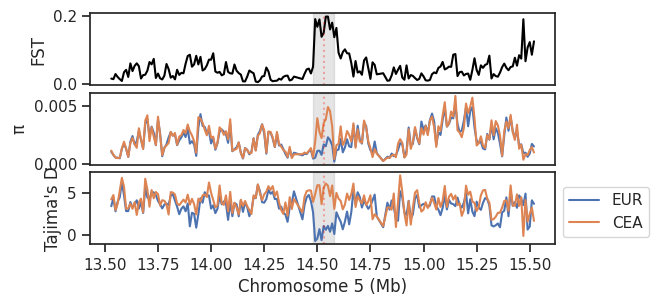

In [36]:
plot_selection_region(fst, pi, tajimad, chrom, (pos-1e6, pos+1e6),
                      highlight=pos, highlight_range=region_highlight_range, figsize=(6, 3))
plt.savefig("pdf/CCL25_region.pdf", bbox_inches='tight')

/storage/public/home/2020060185/.local/lib/python3.10/site-packages/allel/io/vcf_read.py:1042: UserWarning: tabix not found, falling back to scanning to region
  warnings.warn('tabix not found, falling back to scanning to region')


862 biallelic sites were remained.
loaded (862, 2863, 2)
862 sites are remains.


<Figure size 640x480 with 0 Axes>

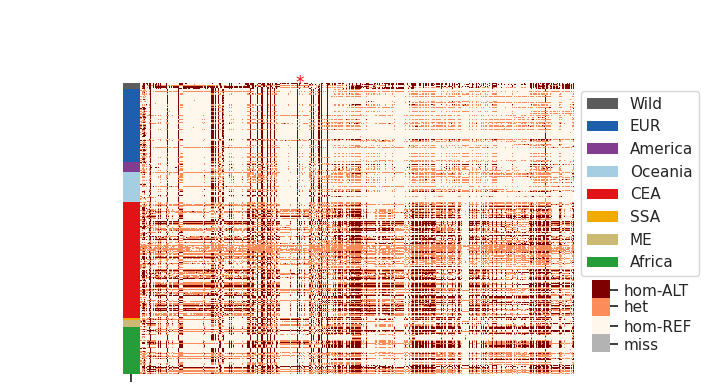

In [37]:
plot_haplotype_heatmap(ref_group_file, ref_vcf_file, region_highlight, groupcolor_file, highlight=pos, figsize=(6, 4))
#plt.savefig(f'plot/{outprefix}.2.png', dpi=300, bbox_inches='tight')
plt.savefig("pdf/CCL25_breed.pdf", bbox_inches='tight')

In [38]:
nominal_file1 = f'{path}/{tissue}/results/tensorqtl/nominal/{tissue}.{group1}.cis_qtl_pairs.{chrom}.txt.gz'
perm_file1 = f'{path}/{tissue}/results/tensorqtl/permutation/{tissue}.{group1}.cis_qtl_fdr0.05.txt.gz'
plink_prefix1 = f'{path}/{tissue}/genotypes/{tissue}.{group1}'
sample_size1 = dftis.loc[(dftis['Tissue']==tissue)&((dftis['group']==group1)), 'Sample size'].values[0]
ld_prefix1 = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{group1}'
title1 = f'{phenotype_id} in {tissue} ({group2abbr[group1]}, n={sample_size1})'
os.makedirs(f'{path}/{tissue}/local/locuszoom/{phenotype_id}', exist_ok=True)
locuszoom_df1, pval_nominal_threshold1, variant_id = load_qtl(nominal_file1, perm_file1, plink_prefix1, ld_prefix1, phenotype_id, variant_id=variant_id)

In [39]:
nominal_file2 = f'{path}/{tissue}/results/tensorqtl/nominal/{tissue}.{group2}.cis_qtl_pairs.{chrom}.txt.gz'
perm_file2 = f'{path}/{tissue}/results/tensorqtl/permutation/{tissue}.{group2}.cis_qtl_fdr0.05.txt.gz'
plink_prefix2 = f'{path}/{tissue}/genotypes/{tissue}.{group2}'
sample_size2 = dftis.loc[(dftis['Tissue']==tissue)&((dftis['group']==group2)), 'Sample size'].values[0]
ld_prefix2 = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{group2}'
title2 = f'{phenotype_id} in {tissue} ({group2abbr[group2]}, n={sample_size2})'
os.makedirs(f'{path}/{tissue}/local/locuszoom/{phenotype_id}', exist_ok=True)
locuszoom_df2, pval_nominal_threshold2, variant_id = load_qtl(nominal_file2, perm_file2, plink_prefix2, ld_prefix2, phenotype_id, variant_id=variant_id)

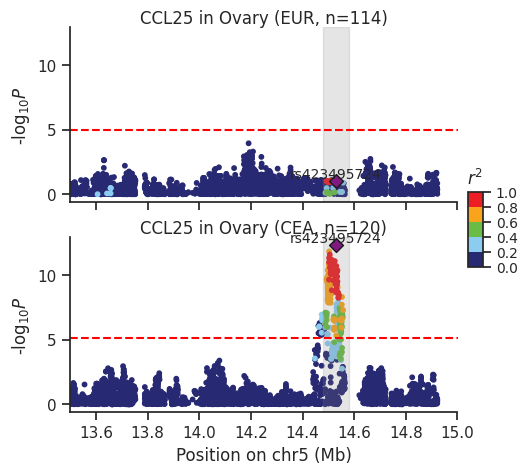

In [40]:
plot_compare_locus2(locuszoom_df1, locuszoom_df2, pval_nominal_threshold1, pval_nominal_threshold2,
                    title1=title1, title2=title2, top_snp=variant_id, rsid=rsid, highlight_range=region_highlight_range, x_axis_range=(13.5, 15), figsize=(5, 5))
#plt.savefig(f'plot/{outprefix}.3.png', dpi=300, bbox_inches='tight')
plt.savefig("pdf/CCL25_qtl.pdf", bbox_inches='tight')

In [41]:
tmm_df, corrected_tmm_df, ref, alt = load_group_tmm(tmm_file1, tmm_file2, batch_file1, batch_file2, vcf_file, group_file, phenotype_id, variant_id)

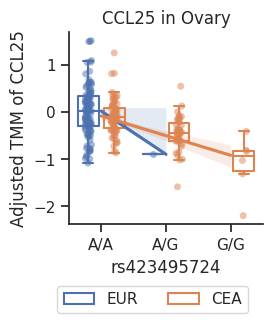

In [42]:
ax = plot_compare_tmm(corrected_tmm_df, variant_id, grouplist=['EUR', 'CEA'], title=None, legend=True, figsize=(2.5, 2.5))
sns.move_legend(ax, "lower left", title=None, ncols=2, bbox_to_anchor=(-0.1, -0.5))
ax.set_xlabel(rsid)
ax.set_ylabel(f'Adjusted TMM of {phenotype_id}')
ax.set_title(f'{phenotype_id} in {tissue}')
plt.savefig("pdf/CCL25_allele.pdf", bbox_inches='tight')

In [19]:
panel_df, ref, alt = load_group_refpanel(ref_vcf_file, ref_group_file, variant_id)
rename_dict = {'Central_and_East_Asia': 'CEA', 'Europe': 'EUR', 'South_and_Southeast_Asia': 'SSA', 'Middle_East': 'ME'}
panel_df_prop = (1-panel_df.groupby('group')['genotype'].mean()/2).sort_values(ascending=False).reset_index().rename(columns={'genotype':ref})
panel_df_prop[alt] = 1 - panel_df_prop[ref]
panel_df_prop['group'] = panel_df_prop['group'].replace(rename_dict)
panel_df_prop = panel_df_prop.set_index('group').reindex(['Wild', 'EUR', 'America', 'Oceania', 'CEA', 'SSA', 'ME', 'Africa'])

In [20]:
panel_df_prop

,A,G
group,,
Wild,0.865079,0.134921
EUR,0.979021,0.020979
America,0.979592,0.020408
Oceania,0.991438,0.008562
CEA,0.766200,0.233800
SSA,0.739130,0.260870
ME,0.957746,0.042254
Africa,0.816993,0.183007


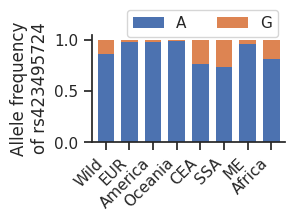

In [44]:
sns.set_theme(style="ticks")
fig =plt.figure(figsize=(2.5, 1.4))
ax = fig.add_subplot()

panel_df_prop.plot(kind='bar', ax=ax, stacked=True, linewidth=0, width=0.7)
plt.ylabel(f'Allele frequency\nof {rsid}')
sns.move_legend(ax, "upper right", ncols=2, bbox_to_anchor=(1, 1.3), title=None)
plt.xticks(rotation=45, ha='right')
plt.xlabel('')
sns.despine()
plt.savefig("pdf/CCL25_ale_breed.pdf", bbox_inches='tight')

## Fig. 8j-n

In [20]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v9.breed_specific/v1.anc"
group1 = 'Europe'
group2 = 'Central_and_East_Asia'
group2abbr = {'Europe':'EUR', 'Central_and_East_Asia':'CEA'}
tissue = 'Abomasum'
phenotype_id = 'RIPK1'
variant_id = '20_49689737'
rsid = 'rs404131822'
chrom = 'chr' + variant_id.split('_')[0]
pos = int(variant_id.split('_')[1])
region_highlight_range=(49650000, 49800000)
region_highlight = f'{chrom}:{region_highlight_range[0]}-{region_highlight_range[1]}'
# from rna-seq
tmm_file1 = f'{path}/{tissue}/phenotypes/{tissue}.{group1}.expression.bed.gz'
tmm_file2 = f'{path}/{tissue}/phenotypes/{tissue}.{group2}.expression.bed.gz'
batch_file1 = f'{path}/{tissue}/covFile/{tissue}.{group1}.tsv'
batch_file2 = f'{path}/{tissue}/covFile/{tissue}.{group2}.tsv'
vcf_file = f'{path}/{tissue}/genotypes/{tissue}.All.vcf.gz'
group_file = f"{path}/{tissue}/{tissue}.plot.grouplist"
# from all data
ref_vcf_file = f'/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/06.population/01.admixture/v1.all/vcf/{chrom}.vcf.gz'
ref_group_file = "/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/06.population/02.selection/01.fst/group.list"
groupcolor_file = "/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/06.population/02.selection/01.fst/groupcolor.list"
# from Chromatin states
state_path = '/storage/public/home/2020060185/genome/sheep/chromHMM_dense'
outprefix = f'{tissue}.{phenotype_id}.{variant_id}'
annot_df = annot[annot['gene_id']==phenotype_id]

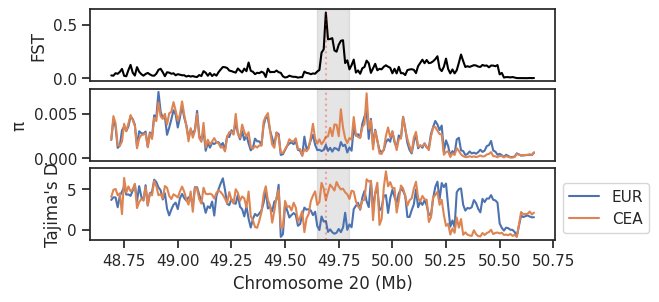

In [25]:
plot_selection_region(fst, pi, tajimad, chrom, (pos-1e6, pos+1e6),
                      highlight=pos, highlight_range=region_highlight_range, figsize=(6, 3))
plt.savefig("pdf/RIPK1_region.pdf", bbox_inches='tight')

/storage/public/home/2020060185/.local/lib/python3.10/site-packages/allel/io/vcf_read.py:1042: UserWarning: tabix not found, falling back to scanning to region
  warnings.warn('tabix not found, falling back to scanning to region')


1200 biallelic sites were remained.
loaded (1200, 2863, 2)
1200 sites are remains.


<Figure size 640x480 with 0 Axes>

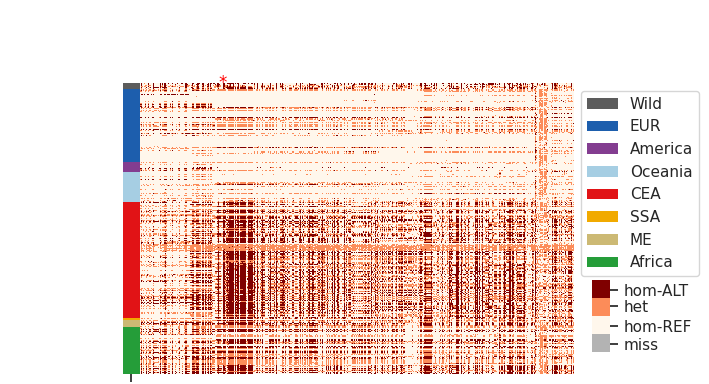

In [26]:
plot_haplotype_heatmap(ref_group_file, ref_vcf_file, region_highlight, groupcolor_file, highlight=pos, figsize=(6, 4))
plt.savefig("pdf/RIPK1_breed.pdf", bbox_inches='tight')

In [27]:
nominal_file1 = f'{path}/{tissue}/results/tensorqtl/nominal/{tissue}.{group1}.cis_qtl_pairs.{chrom}.txt.gz'
perm_file1 = f'{path}/{tissue}/results/tensorqtl/permutation/{tissue}.{group1}.cis_qtl_fdr0.05.txt.gz'
plink_prefix1 = f'{path}/{tissue}/genotypes/{tissue}.{group1}'
sample_size1 = dftis.loc[(dftis['Tissue']==tissue)&((dftis['group']==group1)), 'Sample size'].values[0]
ld_prefix1 = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{group1}'
title1 = f'{phenotype_id} in {tissue} ({group2abbr[group1]}, n={sample_size1})'
os.makedirs(f'{path}/{tissue}/local/locuszoom/{phenotype_id}', exist_ok=True)
locuszoom_df1, pval_nominal_threshold1, variant_id = load_qtl(nominal_file1, perm_file1, plink_prefix1, ld_prefix1, phenotype_id, variant_id=variant_id)

In [28]:
nominal_file2 = f'{path}/{tissue}/results/tensorqtl/nominal/{tissue}.{group2}.cis_qtl_pairs.{chrom}.txt.gz'
perm_file2 = f'{path}/{tissue}/results/tensorqtl/permutation/{tissue}.{group2}.cis_qtl_fdr0.05.txt.gz'
plink_prefix2 = f'{path}/{tissue}/genotypes/{tissue}.{group2}'
sample_size2 = dftis.loc[(dftis['Tissue']==tissue)&((dftis['group']==group2)), 'Sample size'].values[0]
ld_prefix2 = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{group2}'
title2 = f'{phenotype_id} in {tissue} ({group2abbr[group2]}, n={sample_size2})'
os.makedirs(f'{path}/{tissue}/local/locuszoom/{phenotype_id}', exist_ok=True)
locuszoom_df2, pval_nominal_threshold2, variant_id = load_qtl(nominal_file2, perm_file2, plink_prefix2, ld_prefix2, phenotype_id, variant_id=variant_id)

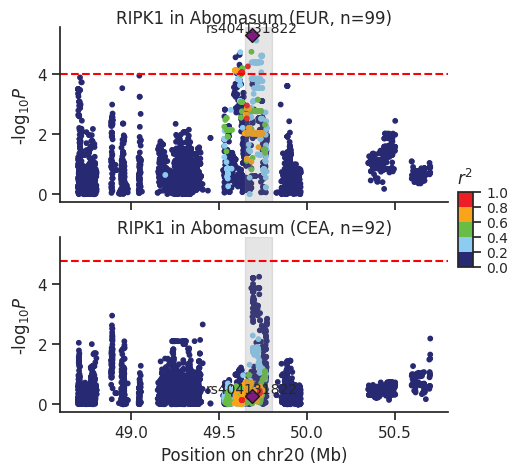

In [29]:
plot_compare_locus2(locuszoom_df1, locuszoom_df2, pval_nominal_threshold1, pval_nominal_threshold2,
                    title1=title1, title2=title2, top_snp=variant_id, rsid=rsid, highlight_range=region_highlight_range, figsize=(5, 5))
plt.savefig("pdf/RIPK1_qtl.pdf", bbox_inches='tight')

In [30]:
tmm_df, corrected_tmm_df, ref, alt = load_group_tmm(tmm_file1, tmm_file2, batch_file1, batch_file2, vcf_file, group_file, phenotype_id, variant_id)

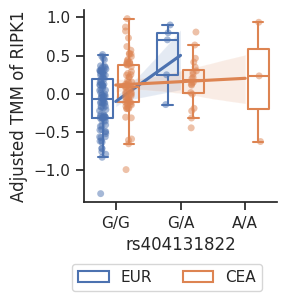

In [31]:
ax = plot_compare_tmm(corrected_tmm_df, variant_id, grouplist=['EUR', 'CEA'], title=None, legend=True, figsize=(2.5, 2.5))
sns.move_legend(ax, "lower left", title=None, ncols=2, bbox_to_anchor=(-0.1, -0.5))
ax.set_xlabel(rsid)
ax.set_ylabel(f'Adjusted TMM of {phenotype_id}')
plt.savefig("pdf/RIPK1_allele.pdf", bbox_inches='tight')

In [21]:
panel_df, ref, alt = load_group_refpanel(ref_vcf_file, ref_group_file, variant_id)
rename_dict = {'Central_and_East_Asia': 'CEA', 'Europe': 'EUR', 'South_and_Southeast_Asia': 'SSA', 'Middle_East': 'ME'}
panel_df_prop = (1-panel_df.groupby('group')['genotype'].mean()/2).sort_values(ascending=False).reset_index().rename(columns={'genotype':ref})
panel_df_prop[alt] = 1 - panel_df_prop[ref]
panel_df_prop['group'] = panel_df_prop['group'].replace(rename_dict)
panel_df_prop = panel_df_prop.set_index('group').reindex(['Wild', 'EUR', 'America', 'Oceania', 'CEA', 'SSA', 'ME', 'Africa'])

In [32]:
panel_df.groupby('group')['genotype'].count()

group
Africa                       459
America                       98
Central_and_East_Asia       1142
Europe                       715
Middle_East                   71
Oceania                      292
South_and_Southeast_Asia      23
Wild                          63
Name: genotype, dtype: int64

In [33]:
panel_df_prop

,G,A
group,,
Wild,1.000000,0.000000
EUR,0.968531,0.031469
America,1.000000,0.000000
Oceania,0.981164,0.018836
CEA,0.917688,0.082312
SSA,0.739130,0.260870
ME,0.732394,0.267606
Africa,0.872549,0.127451


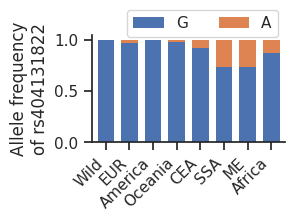

In [34]:
sns.set_theme(style="ticks")
fig =plt.figure(figsize=(2.5, 1.4))
ax = fig.add_subplot()

panel_df_prop.plot(kind='bar', ax=ax, stacked=True, linewidth=0, width=0.7)
plt.ylabel(f'Allele frequency\nof {rsid}')
sns.move_legend(ax, "upper right", ncols=2, bbox_to_anchor=(1, 1.3), title=None)
plt.xticks(rotation=45, ha='right')
plt.xlabel('')
sns.despine()
plt.savefig("pdf/RIPK1_ale_breed.pdf", bbox_inches='tight')